In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("C:/Users/DELL PRECISION 7550/Downloads/Tai_lieu_hoc_tap/Ki_3_2025_2026/He_nhung/smart_greenhouse/BTL_He_nhung/phan_mem/data/raw/greenhouse.csv")
print(df.shape)
df.head(10)

(3000, 4)


,Soil Moisture,Temperature,Air Humidity,Pump Data
0,683.802906,29.184908,71.789699,0
1,408.571567,33.707205,77.977391,1
2,659.092074,24.760311,60.776282,1
3,842.929764,32.738515,59.323543,0
4,414.199320,25.692744,66.624914,1
5,487.521226,33.806809,47.774693,1
6,820.856733,32.659495,40.317592,0
7,726.504807,38.083939,50.915951,0
8,939.915978,35.430747,60.822721,0
9,628.397718,34.232923,42.994402,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Soil Moisture  3000 non-null   float64
 1   Temperature    3000 non-null   float64
 2   Air Humidity   3000 non-null   float64
 3   Pump Data      3000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 93.9 KB


In [6]:
df.describe()

,Soil Moisture,Temperature,Air Humidity,Pump Data
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,662.419754,28.443043,59.387209,0.523000
std,187.936297,6.018565,12.428161,0.499554
min,314.511016,18.002132,38.000201,0.000000
25%,501.362575,23.320750,48.661993,0.000000
50%,666.578554,28.361854,58.975423,1.000000
75%,821.867423,33.595989,70.138397,1.000000
max,984.828010,38.992770,81.267407,1.000000


In [7]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [9]:
numeric_cols = df.select_dtypes(include=np.number)

np.isinf(numeric_cols).sum()

Soil Moisture    0
Temperature      0
Air Humidity     0
Pump Data        0
dtype: int64

In [10]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

In [11]:
label_counts = df['Pump Data'].value_counts()

print(label_counts)

Pump Data
1    1569
0    1431
Name: count, dtype: int64


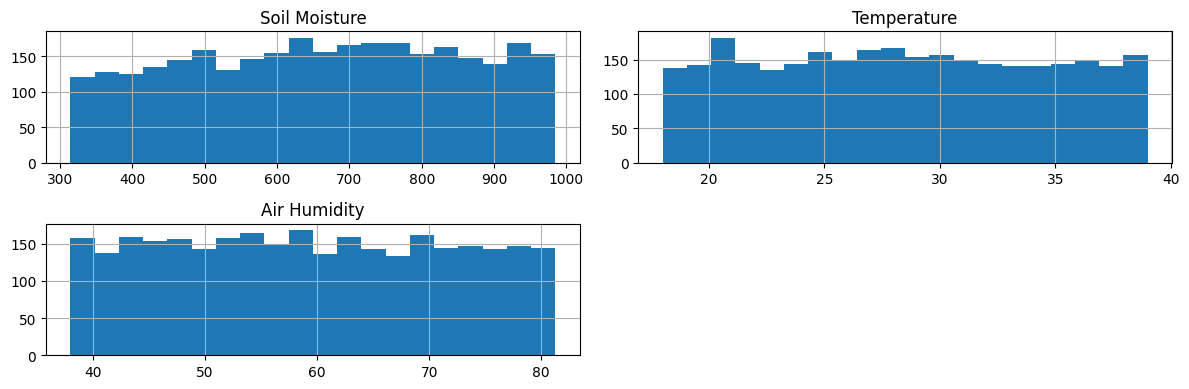

In [17]:
df[["Soil Moisture", "Temperature", "Air Humidity"]].hist(
    figsize=(12, 4),
    bins=20
)
plt.tight_layout()
plt.show()

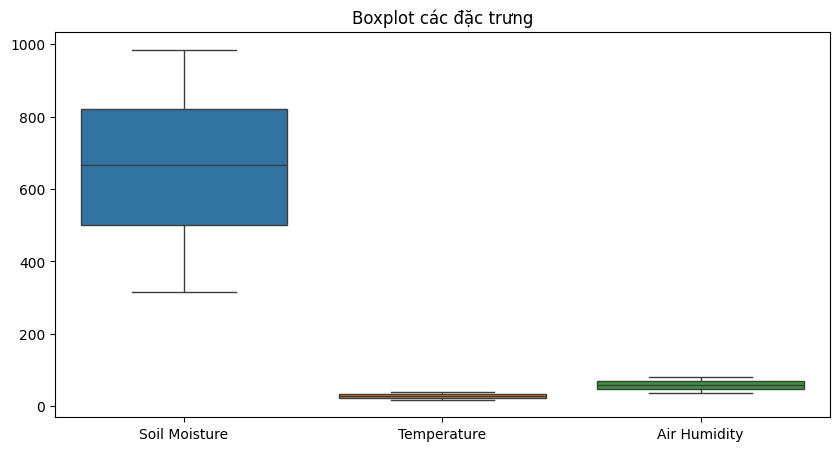

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[["Soil Moisture", "Temperature", "Air Humidity"]])
plt.title("Boxplot các đặc trưng")
plt.show()

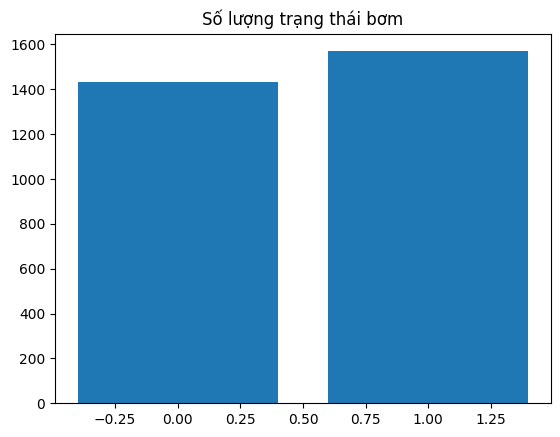

In [23]:
plt.bar(label_counts.index,label_counts.values)
plt.title("Số lượng trạng thái bơm")
plt.show()

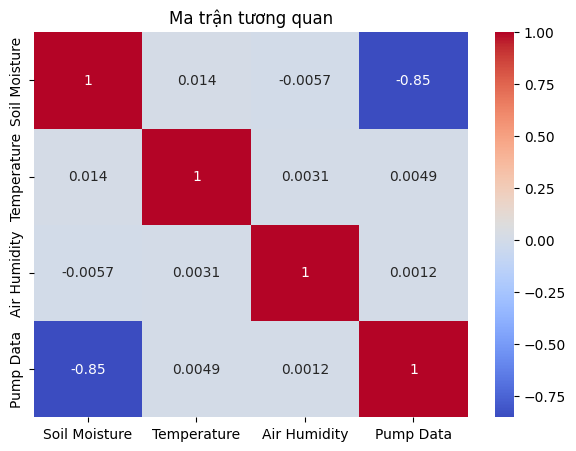

In [20]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Ma trận tương quan")
plt.show()

<Axes: xlabel='Pump Data', ylabel='Soil Moisture'>

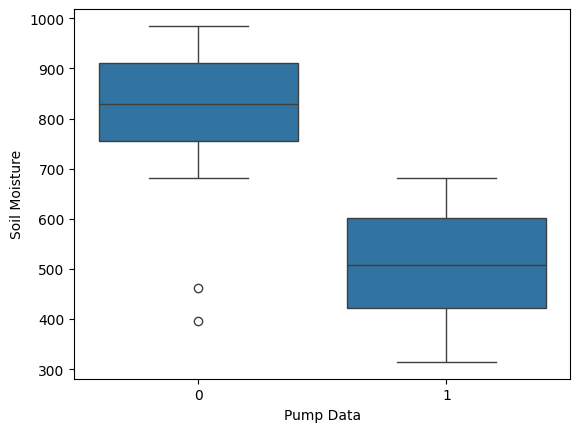

In [12]:
sns.boxplot(
    data=df,
    x="Pump Data",
    y="Soil Moisture"
)

In [13]:
X = df.drop('Pump Data', axis=1)
y = df['Pump Data']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
import joblib
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [16]:
feature_names = X.columns

pd.DataFrame(
    X_train,
    columns=feature_names
).to_csv(
    "../data/processed/X_train.csv",
    index=False
)

pd.DataFrame(
    X_test,
    columns=feature_names
).to_csv(
    "../data/processed/X_test.csv",
    index=False
)

pd.DataFrame(y_train).to_csv(
    "../data/processed/y_train.csv",
    index=False
)

pd.DataFrame(y_test).to_csv(
    "../data/processed/y_test.csv",
    index=False
)